Available chunk files: ['FineGridEval_10_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_20_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_30_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_40_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl']
Loading LATEST chunk: FineGridEval_40_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl (chunk 40)
Loaded 40 cumulative simulations from chunk 40

Columns in combined simulation results:
Index(['sim_run', 'T1', 'T2', 'Initial_1_S', 'Initial_1_CI_lower',
       'Initial_1_CI_upper', 'Final_5_S', 'Final_5_CI_lower',
       'Final_5_CI_upper', 'NPMLE_Targeted_S', 'NPMLE_Targeted_CI_lower',
       'NPMLE_Targeted_CI_upper', 'true_survival'],
      dtype='object')

CONFIDENCE INTERVAL COVERAGE ANALYSIS


/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_10150/1664406713.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage_dict[method] = grouped.apply(
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_10150/1664406713.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ci_length_dict[method] = grouped.apply(



Overall CI Coverage Averages Across Simulation Iterations:
Method Initial_1: Average CI Coverage = 0.9900, Average CI Length = 0.8719
Method Final_5: Average CI Coverage = 0.9900, Average CI Length = 0.8465
Method NPMLE_Targeted: Average CI Coverage = 0.9743, Average CI Length = 1.0666


/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_10150/1664406713.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_coverage, labels=methods)


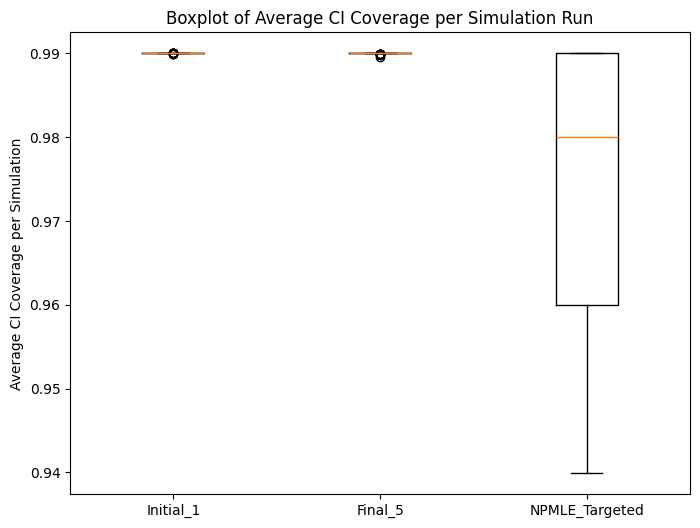

/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_10150/1664406713.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_ci_length, labels=methods)


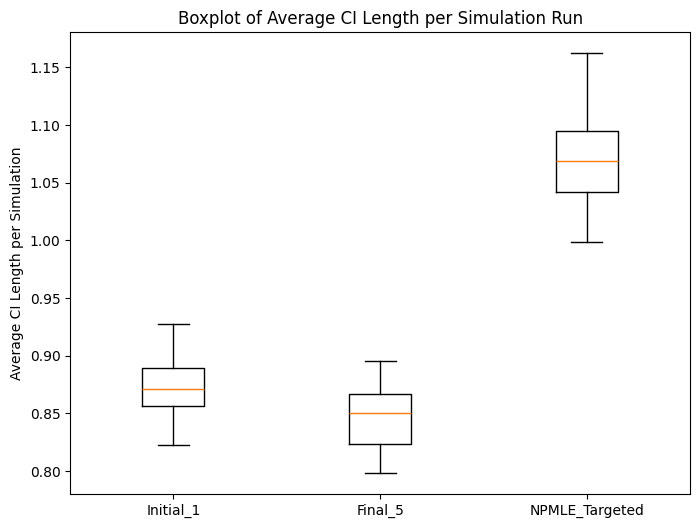

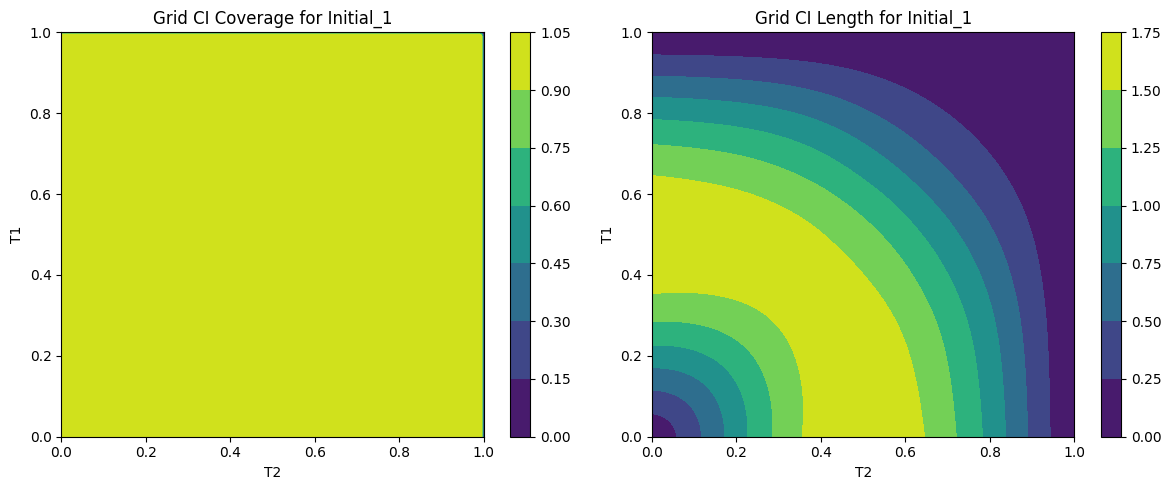

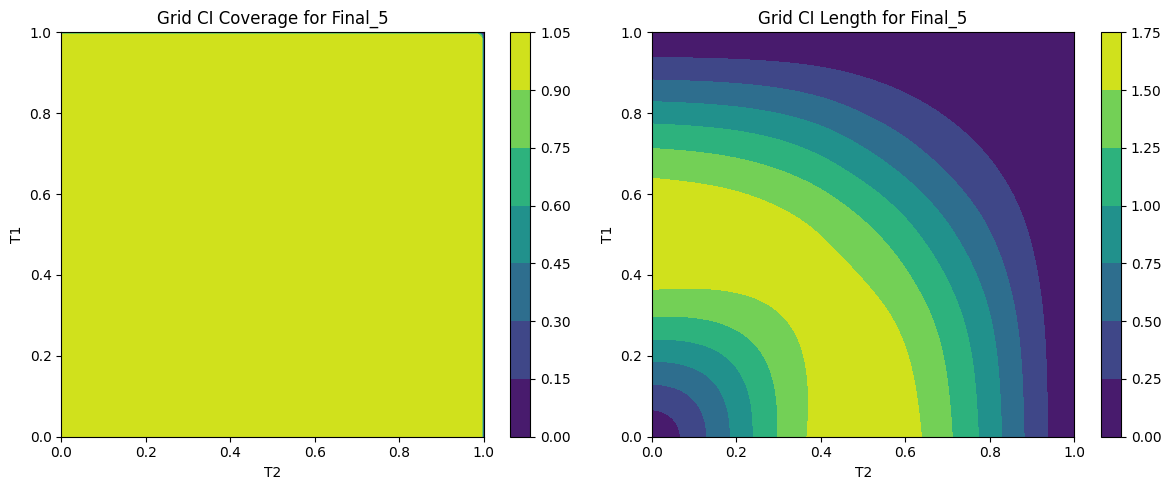

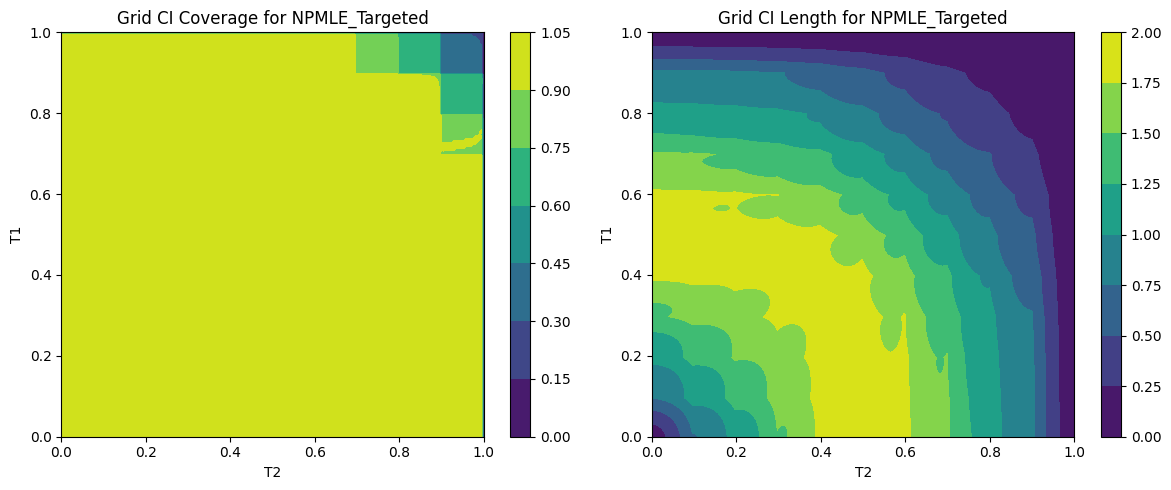

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob

# =============================================================================
# Section 0: Load and Preprocess
# =============================================================================
script_dir = os.getcwd()
parent_dir = os.path.dirname(script_dir)

# Find all uncensored survival result files and use the LATEST chunk
pattern = os.path.join(parent_dir, 'out', 'FineGridEval_*_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl')
result_files = sorted(glob.glob(pattern))

if len(result_files) == 0:
    raise FileNotFoundError(f"No result files found matching pattern: {pattern}")

# Load the latest chunk (cumulative results)
latest_file = result_files[-1]
chunk_num = os.path.basename(latest_file).split('_')[1]

print(f"Available chunk files: {[os.path.basename(f) for f in result_files]}")
print(f"Loading LATEST chunk: {os.path.basename(latest_file)} (chunk {chunk_num})")

with open(latest_file, 'rb') as f:
    survival_dfs = pickle.load(f)

# If the loaded object is a tuple, convert it to a list.
if isinstance(survival_dfs, tuple):
    survival_dfs = list(survival_dfs)

print(f"Loaded {len(survival_dfs)} cumulative simulations from chunk {chunk_num}")

# =============================================================================
# Section 1: Load and Combine Simulation Results
# =============================================================================
df_all = pd.concat(survival_dfs, keys=range(len(survival_dfs)), names=['sim_run'])
df_all = df_all.reset_index(level='sim_run').reset_index(drop=True)

print("\nColumns in combined simulation results:")
print(df_all.columns)

# =============================================================================
# Section 2: CI-Based Coverage Summaries (Grid Pointwise and Per-Simulation)
# =============================================================================
print("\n" + "="*80)
print("CONFIDENCE INTERVAL COVERAGE ANALYSIS")
print("="*80)

# Define methods based on the CI columns.
methods = ['Initial_1', 'Final_5','NPMLE_Targeted']

# -- Grid Pointwise Summaries: Coverage and CI Length --
grouped = df_all.groupby(['T1', 'T2'])
coverage_dict = {}
ci_length_dict = {}

for method in methods:
    # CI Coverage: proportion of simulation runs where the true value is within the CI.
    coverage_dict[method] = grouped.apply(
        lambda df: np.mean((df['true_survival'] >= df[f'{method}_CI_lower']) &
                             (df['true_survival'] <= df[f'{method}_CI_upper']))
    )
    # CI length: average CI width at that grid point.
    ci_length_dict[method] = grouped.apply(
        lambda df: np.mean(df[f'{method}_CI_upper'] - df[f'{method}_CI_lower'])
    )

df_grid_coverage = pd.DataFrame({f'{m}_CI_coverage': coverage_dict[m] for m in methods}).reset_index()
df_grid_ci_length = pd.DataFrame({f'{m}_CI_length': ci_length_dict[m] for m in methods}).reset_index()

# -- Per-Simulation Summaries: Average (over grid) Coverage and CI Length --
sim_summary_list = []
for sim, df_sim in df_all.groupby('sim_run'):
    summary = {'sim_run': sim}
    for method in methods:
        cov_rate = np.mean((df_sim['true_survival'] >= df_sim[f'{method}_CI_lower']) &
                           (df_sim['true_survival'] <= df_sim[f'{method}_CI_upper']))
        avg_ci_length = np.mean(df_sim[f'{method}_CI_upper'] - df_sim[f'{method}_CI_lower'])
        summary[f'{method}_CI_coverage_avg'] = cov_rate
        summary[f'{method}_CI_length_avg'] = avg_ci_length
    sim_summary_list.append(summary)

df_sim_summary = pd.DataFrame(sim_summary_list)

print("\nOverall CI Coverage Averages Across Simulation Iterations:")
for method in methods:
    overall_coverage = df_sim_summary[f'{method}_CI_coverage_avg'].mean()
    overall_ci_length = df_sim_summary[f'{method}_CI_length_avg'].mean()
    print(f"Method {method}: Average CI Coverage = {overall_coverage:.4f}, Average CI Length = {overall_ci_length:.4f}")

# -- Box Plots for Per-Simulation Summaries --
plt.figure(figsize=(8, 6))
data_coverage = [df_sim_summary[f'{method}_CI_coverage_avg'] for method in methods]
plt.boxplot(data_coverage, labels=methods)
plt.ylabel('Average CI Coverage per Simulation')
plt.title('Boxplot of Average CI Coverage per Simulation Run')
plt.show()

plt.figure(figsize=(8, 6))
data_ci_length = [df_sim_summary[f'{method}_CI_length_avg'] for method in methods]
plt.boxplot(data_ci_length, labels=methods)
plt.ylabel('Average CI Length per Simulation')
plt.title('Boxplot of Average CI Length per Simulation Run')
plt.show()

# -- Contour Plots for Grid Pointwise Summaries for All Methods --
for method in methods:
    pivot_cov = df_grid_coverage.pivot(index='T1', columns='T2', values=f'{method}_CI_coverage')
    pivot_ci = df_grid_ci_length.pivot(index='T1', columns='T2', values=f'{method}_CI_length')
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    cp1 = plt.contourf(pivot_cov.columns, pivot_cov.index, pivot_cov.values, cmap='viridis')
    plt.colorbar(cp1)
    plt.title(f'Grid CI Coverage for {method}')
    plt.xlabel('T2')
    plt.ylabel('T1')
    
    plt.subplot(1, 2, 2)
    cp2 = plt.contourf(pivot_ci.columns, pivot_ci.index, pivot_ci.values, cmap='viridis')
    plt.colorbar(cp2)
    plt.title(f'Grid CI Length for {method}')
    plt.xlabel('T2')
    plt.ylabel('T1')
    
    plt.tight_layout()
    plt.show()

In [2]:
# =============================================================================
# Section 3: Oracle Coverage & Point Estimate Performance
# =============================================================================
print("\n" + "="*80)
print("ORACLE COVERAGE & POINT ESTIMATE PERFORMANCE")
print("="*80)

# Compute summaries on the survival surfaces.
methods = ['Initial_1', 'Final_5','NPMLE_Targeted']
grouped_surv = df_all.groupby(['T1', 'T2'])
summary_list = []
for (T1_val, T2_val), group in grouped_surv:
    true_val = group['true_survival'].iloc[0]
    summary = {'T1': T1_val, 'T2': T2_val, 'true_survival': true_val}
    for m in methods:
        # Compute point estimate summaries
        fitted_vals = group[f'{m}_S'].values
        mean_fitted = np.mean(fitted_vals)
        bias = mean_fitted - true_val
        mse = np.mean((fitted_vals - true_val) ** 2)
        std = np.std(fitted_vals)
        
        # Oracle coverage: using empirical standard deviation
        oracle_cov = np.mean((true_val >= (fitted_vals - 1.96 * std)) & 
                            (true_val <= (fitted_vals + 1.96 * std)))
        
        # CI-based coverage (for comparison)
        ci_coverage = np.mean((true_val >= group[f'{m}_CI_lower']) & (true_val <= group[f'{m}_CI_upper']))
        ci_len = np.mean(group[f'{m}_CI_upper'] - group[f'{m}_CI_lower'])
        
        # Store the summaries for each method
        summary[f'{m}_mean'] = mean_fitted
        summary[f'{m}_bias'] = bias
        summary[f'{m}_mse'] = mse
        summary[f'{m}_std'] = std
        summary[f'{m}_oracle_coverage'] = oracle_cov
        summary[f'{m}_CI_coverage'] = ci_coverage
        summary[f'{m}_CI_length'] = ci_len
    summary_list.append(summary)

df_summary = pd.DataFrame(summary_list)

print("\nSurvival Surface Summary (first few rows):")
print(df_summary.head())

print("\nOverall Performance Summary (across grid):")
for m in methods:
    overall_abs_bias = df_summary[f'{m}_bias'].abs().mean()
    overall_std = df_summary[f'{m}_std'].mean()
    overall_mse = df_summary[f'{m}_mse'].mean()
    overall_oracle_cov = df_summary[f'{m}_oracle_coverage'].median()
    overall_ci_cov = df_summary[f'{m}_CI_coverage'].median()
    overall_ci_length = df_summary[f'{m}_CI_length'].median()
    
    print(f"\nMethod {m}:")
    print(f"  Point Estimates: Abs bias = {overall_abs_bias:.4f}, Std = {overall_std:.4f}, MSE = {overall_mse:.4f}")
    print(f"  Oracle Coverage = {overall_oracle_cov:.3f}")
    print(f"  CI Coverage = {overall_ci_cov:.3f}, CI Length = {overall_ci_length:.4f}")


ORACLE COVERAGE & POINT ESTIMATE PERFORMANCE

Survival Surface Summary (first few rows):
    T1        T2  true_survival  Initial_1_mean  Initial_1_bias  \
0  0.0  0.000000       0.999245        0.997545       -0.001701   
1  0.0  0.005025       0.998452        0.996304       -0.002147   
2  0.0  0.010050       0.997618        0.995053       -0.002565   
3  0.0  0.015075       0.996742        0.993785       -0.002957   
4  0.0  0.020101       0.995823        0.992495       -0.003328   

   Initial_1_mse  Initial_1_std  Initial_1_oracle_coverage  \
0       0.000003       0.000650                      0.225   
1       0.000006       0.001033                      0.500   
2       0.000009       0.001429                      0.650   
3       0.000012       0.001831                      0.750   
4       0.000016       0.002235                      0.750   

   Initial_1_CI_coverage  Initial_1_CI_length  ...  Final_5_oracle_coverage  \
0                    1.0             0.027818  ...     


ORACLE COVERAGE ANALYSIS (Empirical Performance)

Overall Oracle Coverage Summary (across full grid):
Method Initial_1_S: Overall abs bias = 0.0027, Overall std = 0.0112, Overall MSE = 0.0002, Oracle Coverage = 0.950
Method Final_5_S: Overall abs bias = 0.0019, Overall std = 0.0111, Overall MSE = 0.0002, Oracle Coverage = 0.950
Method NPMLE_Targeted_S: Overall abs bias = 0.0047, Overall std = 0.0134, Overall MSE = 0.0003, Oracle Coverage = 0.925

Center Region (inside 0.8x0.8) Oracle Coverage Summary:
Center Method Initial_1_S: Overall abs bias = 0.0028, Overall std = 0.0117, Overall MSE = 0.0002, Oracle Coverage = 0.950
Center Method Final_5_S: Overall abs bias = 0.0019, Overall std = 0.0116, Overall MSE = 0.0002, Oracle Coverage = 0.950
Center Method NPMLE_Targeted_S: Overall abs bias = 0.0049, Overall std = 0.0139, Overall MSE = 0.0003, Oracle Coverage = 0.925

Tail Region (outside 0.8x0.8) Oracle Coverage Summary:
Tail Method Initial_1_S: Overall abs bias = 0.0022, Overall std = 0

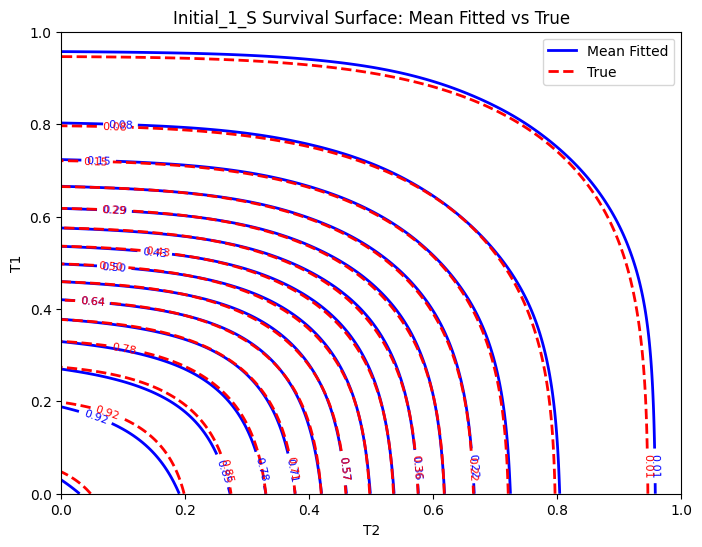

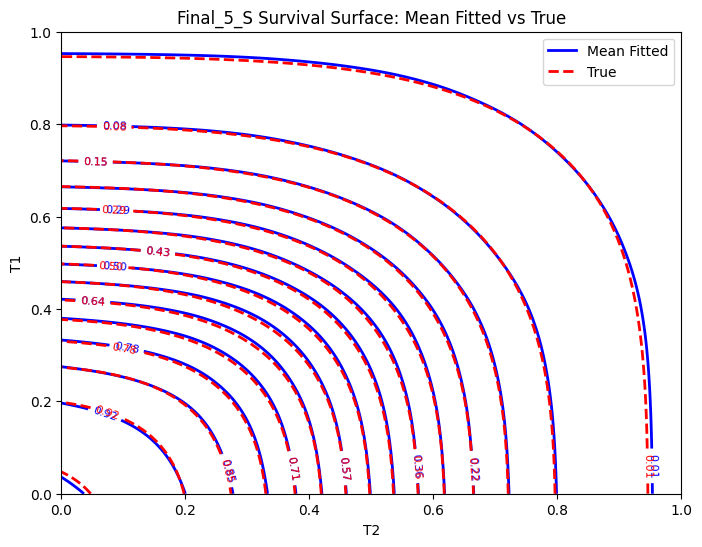

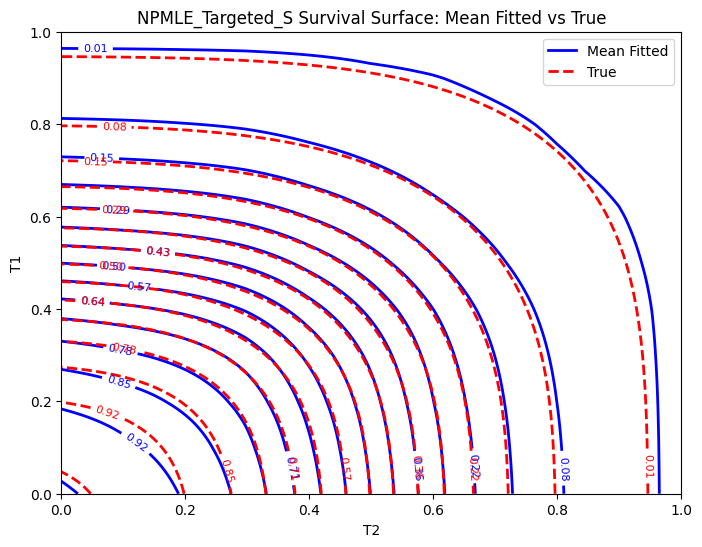

In [3]:
# =============================================================================
# Section 4: Oracle Coverage Analysis (Simplified - matches Summary notebook)
# =============================================================================
print("\n" + "="*80)
print("ORACLE COVERAGE ANALYSIS (Empirical Performance)")
print("="*80)

# Here we use the survival estimate columns (ending in _S) to summarize the fitted survival surfaces.
# We treat these as the "fitted" survival, and compare them to the true survival.
# Define survival methods using the "_S" columns.
surv_methods = ['Initial_1_S', 'Final_5_S','NPMLE_Targeted_S']

summary_list = []
# Group by grid coordinates.
grouped_surv = df_all.groupby(['T1', 'T2'])
for (T1_val, T2_val), group in grouped_surv:
    true_val = group['true_survival'].iloc[0]
    summary = {'T1': T1_val, 'T2': T2_val, 'true_survival': true_val}
    for col in surv_methods:
        fitted_vals = group[col].values
        mean_fitted = np.mean(fitted_vals)
        bias = mean_fitted - true_val
        mse = np.mean((fitted_vals - true_val)**2)
        std = np.std(fitted_vals)
        lower_nom = mean_fitted - 1.96 * std
        upper_nom = mean_fitted + 1.96 * std
        oracle_coverage = np.mean((true_val >= (fitted_vals - 1.96 * std)) & (true_val <= (fitted_vals + 1.96 * std)))
        
        summary[f'{col}_mean'] = mean_fitted
        summary[f'{col}_bias'] = bias
        summary[f'{col}_mse'] = mse
        summary[f'{col}_std'] = std
        summary[f'{col}_lower'] = lower_nom
        summary[f'{col}_upper'] = upper_nom
        summary[f'{col}_oracle_coverage'] = oracle_coverage
    summary_list.append(summary)

df_summary_oracle = pd.DataFrame(summary_list)

# Overall summary statistics across the grid.
print("\nOverall Oracle Coverage Summary (across full grid):")
for col in surv_methods:
    overall_abs_bias = df_summary_oracle[f'{col}_bias'].abs().mean()
    overall_std = df_summary_oracle[f'{col}_std'].mean()
    overall_mse = df_summary_oracle[f'{col}_mse'].mean()
    overall_oracle_cov = df_summary_oracle[f'{col}_oracle_coverage'].median()
    print(f"Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, "
          f"Overall MSE = {overall_mse:.4f}, Oracle Coverage = {overall_oracle_cov:.3f}")

# Optionally, analyze by regions: center (T1 < 0.8 or T2 < 0.8) and tail (T1 > 0.8 or T2 > 0.8).
# Center region:
df_center = df_summary_oracle[(df_summary_oracle['T1'] < 0.8) | (df_summary_oracle['T2'] < 0.8)]
print("\nCenter Region (inside 0.8x0.8) Oracle Coverage Summary:")
for col in surv_methods:
    overall_abs_bias = df_center[f'{col}_bias'].abs().mean()
    overall_std = df_center[f'{col}_std'].mean()
    overall_mse = df_center[f'{col}_mse'].mean()
    overall_oracle_cov = df_center[f'{col}_oracle_coverage'].median()
    print(f"Center Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, "
          f"Overall MSE = {overall_mse:.4f}, Oracle Coverage = {overall_oracle_cov:.3f}")

# Tail region:
df_tail = df_summary_oracle[(df_summary_oracle['T1'] > 0.8) | (df_summary_oracle['T2'] > 0.8)]
print("\nTail Region (outside 0.8x0.8) Oracle Coverage Summary:")
for col in surv_methods:
    overall_abs_bias = df_tail[f'{col}_bias'].abs().mean()
    overall_std = df_tail[f'{col}_std'].mean()
    overall_mse = df_tail[f'{col}_mse'].mean()
    overall_oracle_cov = df_tail[f'{col}_oracle_coverage'].median()
    print(f"Tail Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, "
          f"Overall MSE = {overall_mse:.4f}, Oracle Coverage = {overall_oracle_cov:.3f}")

# =============================================================================
# Section 5: Contour Plots for Survival Surface Comparison
# =============================================================================
# For each survival method, plot the mean fitted survival surface vs the true survival surface.
for col in surv_methods:
    pivot_mean = df_summary_oracle.pivot(index='T1', columns='T2', values=f'{col}_mean')
    pivot_std = df_summary_oracle.pivot(index='T1', columns='T2', values=f'{col}_std')
    pivot_true = df_summary_oracle.pivot(index='T1', columns='T2', values='true_survival')
    
    # Create grid arrays.
    T1_vals = pivot_mean.index.values
    T2_vals = pivot_mean.columns.values
    T2_grid, T1_grid = np.meshgrid(T2_vals, T1_vals)
    
    mean_fitted = pivot_mean.values
    lower = mean_fitted - 1.96 * pivot_std.values
    upper = mean_fitted + 1.96 * pivot_std.values

    # Define contour levels (e.g., survival probabilities).
    levels_surv = np.linspace(0.01, 0.99, 15)
    
    plt.figure(figsize=(8, 6))
    
    # Plot the mean fitted survival surface (blue solid lines).
    cp1 = plt.contour(T2_grid, T1_grid, mean_fitted, levels=levels_surv,
                      colors='blue', linewidths=2, linestyles='-')
    plt.clabel(cp1, inline=True, fontsize=8, fmt='%.2f')
    
    # Plot the true survival surface (red dashed lines).
    cp2 = plt.contour(T2_grid, T1_grid, pivot_true.values, levels=levels_surv,
                      colors='red', linewidths=2, linestyles='--')
    plt.clabel(cp2, inline=True, fontsize=8, fmt='%.2f')
    
    # Custom legend.
    legend_elements = [
         Line2D([0], [0], color='blue', lw=2, linestyle='-', label='Mean Fitted'),
         Line2D([0], [0], color='red', lw=2, linestyle='--', label='True')
    ]
    plt.legend(handles=legend_elements)
    
    plt.title(f'{col} Survival Surface: Mean Fitted vs True')
    plt.xlabel('T2')
    plt.ylabel('T1')
    plt.show()